# IMPORTS

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest , GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw , integrated_brier_score
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import category_encoders as ce
import mygene
from sklearn.preprocessing import MultiLabelBinarizer

In [2]:
mol_df = pl.read_csv("../data/processed/X_train/molecular_train_final.csv")
cl_df = pl.read_csv("../data/processed/X_train/clinical_train_preprocess.csv")
y = pl.read_csv("../data/processed/target_preprocess.csv")

In [3]:
mol_df

ID,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,CHR_mean,CHR_max,CHR_min,has_3_prime_UTR_variant,has_2KB_upstream_variant,has_non_synonymous_codon,has_PTD,has_inframe_codon_gain,has_initiator_codon_change,has_frameshift_variant,has_ITD,has_inframe_variant,has_synonymous_codon,has_stop_gained,has_inframe_codon_loss,has_splice_site_variant,has_complex_change_in_transcript,has_stop_lost,REF_length,ALT_length,is_transition,is_transversion,is_indel
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64
"""P120806""",0.25,0.09748,0.222,0.039,0.407069,0.513781,0.301283,0.338702,0.523359,0.006479,0.372727,19.0,1.0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0.008621,0.113636,1,0,1
"""P122465""",0.1875,0.357525,0.5254,0.025,0.416684,0.516726,0.217547,0.524394,0.875452,0.146741,0.295455,20.0,2.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0.006897,0.068182,0,1,1
"""P116650""",0.0,0.4809,0.4809,0.4809,0.467494,0.467494,0.467494,0.452902,0.418355,0.455964,0.590909,14.0,14.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.008621,0.011364,0,0,1
"""P105501""",0.0625,0.431,0.48,0.382,0.836945,0.841574,0.832316,0.835978,0.875449,0.725759,0.159091,7.0,2.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.003448,0.022727,1,1,0
"""P100283""",0.1875,0.4392,0.67,0.335,0.350515,0.539449,0.227225,0.25345,0.587426,0.034417,0.875,23.0,17.0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0.031034,0.045455,1,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P105971""",0.1875,0.293575,0.4783,0.021,0.663581,0.858405,0.519672,0.405554,0.875451,0.060655,0.261364,19.0,2.0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0.006897,0.079545,1,1,1
"""P100303""",0.0,0.0598,0.0598,0.0598,0.390911,0.390911,0.390911,0.947741,0.875449,0.948034,0.045455,2.0,2.0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0.017241,0.045455,0,0,1
"""P105722""",0.4375,0.2591375,0.466,0.022,0.651247,1.0,0.111088,0.237841,0.523422,0.006479,0.284091,20.0,1.0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0.015517,0.397727,1,1,1


In [4]:
cl_df

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""P132697""",0.756757,0.209677,0.02589,0.7,0.291667,0.246835,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P132698""",0.054054,0.580645,0.31068,0.1,0.662037,0.084388,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P116889""",0.810811,0.282258,0.271845,0.1,0.902778,0.166667,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
"""P132699""",0.054054,0.298387,0.245955,0.1,0.412037,0.158228,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P132700""",0.324324,1.0,1.0,0.9,0.615741,0.407173,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",0.054054,0.282258,0.327508,0.53,0.412037,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""P121829""",0.0,0.322581,0.31068,0.22,0.569444,0.099156,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1
"""P121830""",0.0,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0


In [5]:
y

ID,time,event
str,f64,bool
"""P132697""",1.115068,true
"""P132698""",4.928767,false
"""P116889""",2.043836,false
"""P132699""",2.476712,true
"""P132700""",3.145205,false
…,…,…
"""P121828""",2.932591,false
"""P121829""",2.932591,false
"""P121830""",1.99726,false


# MISSING PATIENTS IN MOLECULAR DATAFRAME

In [6]:
cl_ids = cl_df.select("ID").unique().to_numpy()
mol_ids = mol_df.select("ID").unique().to_numpy()

cpt = 0
for id in cl_ids:
    if id not in mol_ids:
        print(f"This patient {id} has no molecular information ! ")
        cpt+=1

print("------------------------------------")
print(f"Total of patients {cpt}")

This patient ['P105810'] has no molecular information ! 
This patient ['P131873'] has no molecular information ! 
This patient ['P118437'] has no molecular information ! 
This patient ['P118031'] has no molecular information ! 
This patient ['P105916'] has no molecular information ! 
This patient ['P102582'] has no molecular information ! 
This patient ['P116585'] has no molecular information ! 
This patient ['P116764'] has no molecular information ! 
This patient ['P117397'] has no molecular information ! 
This patient ['P110857'] has no molecular information ! 
This patient ['P105872'] has no molecular information ! 
This patient ['P100178'] has no molecular information ! 
This patient ['P116346'] has no molecular information ! 
This patient ['P122359'] has no molecular information ! 
This patient ['P122411'] has no molecular information ! 
This patient ['P105947'] has no molecular information ! 
This patient ['P105532'] has no molecular information ! 
This patient ['P116817'] has no

# MERGING THE DATAFRAMES

In [7]:
final_df = (
    cl_df
    .join(mol_df , on="ID" , how="left")
    .join(y,on="ID",how="left")
)

In [8]:
final_df

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,CHR_mean,CHR_max,CHR_min,has_3_prime_UTR_variant,has_2KB_upstream_variant,has_non_synonymous_codon,has_PTD,has_inframe_codon_gain,has_initiator_codon_change,has_frameshift_variant,has_ITD,has_inframe_variant,has_synonymous_codon,has_stop_gained,has_inframe_codon_loss,has_splice_site_variant,has_complex_change_in_transcript,has_stop_lost,REF_length,ALT_length,is_transition,is_transversion,is_indel,time,event
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64,f64,bool
"""P132697""",0.756757,0.209677,0.02589,0.7,0.291667,0.246835,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.5,0.251578,0.422,0.03,0.683732,1.0,0.185988,0.189604,0.465655,0.120077,0.515152,21.0,1.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0.015517,0.147727,1,1,1,1.115068,true
"""P132698""",0.054054,0.580645,0.31068,0.1,0.662037,0.084388,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.125,0.272867,0.2825,0.2661,0.58293,0.985904,0.330738,0.106457,0.154028,0.016224,0.818182,21.0,16.0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0.005172,0.056818,1,0,1,4.928767,false
"""P116889""",0.810811,0.282258,0.271845,0.1,0.902778,0.166667,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.125,0.039333,0.048,0.035,0.73792,0.838207,0.616874,0.601459,0.875451,0.15341,0.257576,11.0,2.0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0.005172,0.034091,1,1,0,2.043836,false
"""P132699""",0.054054,0.298387,0.245955,0.1,0.412037,0.158228,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.625,0.209227,0.477,0.049,0.475451,0.703135,0.153587,0.318923,0.654018,0.074004,0.644628,23.0,7.0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0.058621,0.136364,1,1,1,2.476712,true
"""P132700""",0.324324,1.0,1.0,0.9,0.615741,0.407173,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.0,0.4721,0.4721,0.4721,0.293288,0.293288,0.293288,0.141938,0.131111,0.146741,0.863636,20.0,20.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0.001724,0.022727,0,0,1,3.145205,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",0.054054,0.282258,0.327508,0.53,0.412037,1.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0625,0.397,0.41,0.384,0.286766,0.346308,0.227225,0.169665,0.182335,0.146741,0.818182,20.0,18.0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0.003448,0.034091,0,1,1,2.932591,false
"""P121829""",0.0,0.322581,0.31068,0.22,0.569444,0.099156,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0.0,0.042,0.042,0.042,0.305912,0.305912,0.305912,0.24991,0.230847,0.254109,1.0,23.0,23.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.001724,0.011364,1,0,0,2.932591,false
"""P121830""",0.0,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0.3125,0.24465,0.439,0.028,0.316782,0.527667,0.122449,0.383896,0.679769,0.022417,0.568182,23.0,1.0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0.012069,0.068182,1,1,1,1.99726,false


# NULL VALUES

In [9]:
final_df.null_count()

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,CHR_mean,CHR_max,CHR_min,has_3_prime_UTR_variant,has_2KB_upstream_variant,has_non_synonymous_codon,has_PTD,has_inframe_codon_gain,has_initiator_codon_change,has_frameshift_variant,has_ITD,has_inframe_variant,has_synonymous_codon,has_stop_gained,has_inframe_codon_loss,has_splice_site_variant,has_complex_change_in_transcript,has_stop_lost,REF_length,ALT_length,is_transition,is_transversion,is_indel,time,event
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,298,0,0


In [10]:
def imputation_null_values(df, column_list, estimator=None):
    """
    Impute missing values using iterative imputation.

    Parameters:
    -----------
    df : pl.DataFrame
        DataFrame containing columns with missing values
    column_list : list
        List of column names to impute
    estimator : object, default=None
        Estimator for IterativeImputer (defaults to RandomForestRegressor if None)

    Returns:
    --------
    pl.DataFrame
        DataFrame with imputed values

    Raises:
    -------
    ValueError
        If input is not a Polars DataFrame or columns don't exist
    """
    if not isinstance(df, pl.DataFrame):
        raise ValueError("Input must be a Polars DataFrame")

    missing_columns = [col for col in column_list if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing columns for imputation: {', '.join(missing_columns)}")

    # Check if there are any null values to impute
    null_counts = {col: df.select(pl.col(col).is_null().sum())[0, 0] for col in column_list}
    if sum(null_counts.values()) == 0:
        return df  # No nulls to impute

    try:
        # Select subset of dataframe
        sub_df = df.select(column_list)

        # Convert to pandas
        sub_pd = sub_df.to_pandas()
        

        # Apply imputation
        imputer = IterativeImputer(estimator=estimator, random_state=42)
        imputed_data = imputer.fit_transform(sub_pd)

        # Convert back to polars
        imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

        # Replace nulls in original dataframe
        df = df.with_columns([imputed_pl[col].alias(col) for col in column_list])

        return df
    except Exception as e:
        raise ValueError(f"Error during imputation: {str(e)}")

In [11]:
from sklearn.tree import DecisionTreeRegressor

cols = mol_df.columns

cols.remove("ID")

final_df = imputation_null_values(final_df,cols , estimator=DecisionTreeRegressor())

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [12]:
final_dfnoID = final_df.drop("ID")

# BEFORE FEATURE SELECTION

In [13]:
X = final_dfnoID.drop(["time"  , "event"])

y = Surv.from_dataframe(event="event"  , time="time" , data=final_dfnoID.to_pandas())

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 ,random_state=42)

models = {"CoxPH": CoxPHSurvivalAnalysis(alpha=1e-4, n_iter=1000),
        "Random Survival Forest": RandomSurvivalForest(n_estimators=100, min_samples_split=10, min_samples_leaf=15, random_state=42),
        "GradientBoosting" : GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0)
    }

In [15]:
# Appliquer les modèles et afficher le C-index
for name, model in models.items():
    model.fit(X_train, y_train)
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
    test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
    
    
    
    print("----------")
    
    
    print(f"{name} Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
    print(f"{name} Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")
    

----------
CoxPH Survival Model Concordance Index IPCW on train: 0.72
CoxPH Survival Model Concordance Index IPCW on test: 0.69
----------
Random Survival Forest Survival Model Concordance Index IPCW on train: 0.79
Random Survival Forest Survival Model Concordance Index IPCW on test: 0.70
----------
GradientBoosting Survival Model Concordance Index IPCW on train: 0.74
GradientBoosting Survival Model Concordance Index IPCW on test: 0.70


In [ ]:
from lifelines import CoxPHFitter

df_filtered_pd = final_dfnoID.to_pandas()

cph = CoxPHFitter(penalizer=0.01)
cph.fit(df_filtered_pd , duration_col='time', event_col='event')

# Summary
cph.print_summary()

summary_df = cph.summary

<lifelines.CoxPHFitter: fitted with 3323 total observations, 1723 right-censored observations>
             duration col = 'time'
                event col = 'event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3323
number of events observed = 1600
   partial log-likelihood = -11185.91
         time fit was run = 2025-06-25 17:07:58 UTC

---
                                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                         
BM_BLAST                          0.71      2.03      0.09            0.53            0.89                1.70                2.43
WBC                               0.26      1.29      0.24           -0.21            0.72                0.81                2.06
ANC                               0.25      1.28      0.20           -0.14            0.64                0.87                1.90
MONOCYTES                        -0.07      0.93      0.07           -0.20            0.06                0.82                1.06
HB                               -1.52      0.22      0.14           -1.80           -1.24                0.16                0.29
PLT                              -0.80      0.45      0.12           -1.03           -0.57                0.36                0.56
is_a_Man                         -0.21      0.81      0.08           -0.36           -0.06                0.70                0.94
is_a_Female                      -0.39      0.67      0.08           -0.56           -0.23                0.57                0.79
is_deletion_anomaly               0.22      1.24      0.07            0.07            0.36                1.08                1.43
is_inversion_anomaly              0.03      1.03      0.18           -0.34            0.39                0.71                1.47
is_added_anomaly                  0.08      1.09      0.12           -0.16            0.33                0.85                1.39
is_down_syndrome                 -0.83      0.44      0.19           -1.21           -0.45                0.30                0.64
is_monosomy                       0.23      1.25      0.13           -0.03            0.48                0.97                1.62
is_7_deleted                      0.14      1.15      0.17           -0.18            0.47                0.83                1.60
is_trisomy_8                     -0.23      0.80      0.13           -0.49            0.03                0.61                1.03
iso_chromosome                   -0.03      0.97      0.25           -0.52            0.45                0.60                1.57
is_derived_chromosome             0.34      1.40      0.15            0.05            0.62                1.05                1.87
is_lost_sex_chromosome           -0.26      0.77      0.13           -0.51           -0.02                0.60                0.98
is_added_chromsome                0.45      1.57      0.12            0.22            0.69                1.25                1.98
is_deleted_chromsome              0.20      1.22      0.13           -0.05            0.46                0.95                1.58
is_inserted_chromsome             0.07      1.07      0.28           -0.48            0.61                0.62                1.84
is_translocated_anomaly          -0.07      0.93      0.12           -0.30            0.16                0.74                1.17
is_complex_karyo                  0.38      1.47      0.12            0.15            0.62                1.16                1.85
GENE_count                        1.27      3.57      0.35            0.59            1.95                1.81                7.04
VAF_mean                          0.81      2.25      0.51           -0.19            1.81                0.83                6.11
VAF_max                           0

In [17]:
# Filtrer les variables avec p-value > 0.01
insignificant_vars = summary_df[summary_df['p'] > 0.05].index.tolist()

print("Variables non significatives (p > 0.05) :", insignificant_vars)

print(f"Taille {len(insignificant_vars)}")

Variables non significatives (p > 0.05) : ['WBC', 'ANC', 'MONOCYTES', 'is_inversion_anomaly', 'is_added_anomaly', 'is_monosomy', 'is_7_deleted', 'is_trisomy_8', 'iso_chromosome', 'is_deleted_chromsome', 'is_inserted_chromsome', 'is_translocated_anomaly', 'VAF_mean', 'VAF_max', 'VAF_min', 'DEPTH_mean', 'DEPTH_max', 'DEPTH_min', 'START_max', 'START_min', 'CHR_mean', 'CHR_max', 'CHR_min', 'has_3_prime_UTR_variant', 'has_2KB_upstream_variant', 'has_non_synonymous_codon', 'has_inframe_codon_gain', 'has_initiator_codon_change', 'has_frameshift_variant', 'has_ITD', 'has_inframe_variant', 'has_synonymous_codon', 'has_stop_gained', 'has_inframe_codon_loss', 'has_splice_site_variant', 'has_complex_change_in_transcript', 'has_stop_lost', 'REF_length', 'ALT_length', 'is_indel']
Taille 40


In [18]:
df_significant = df_filtered_pd.drop(columns=insignificant_vars)

df_significant

,BM_BLAST,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_down_syndrome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_complex_karyo,GENE_count,START_mean,has_PTD,is_transition,is_transversion,time,event
0,0.756757,0.291667,0.246835,1,0,1,0,0,0,0,0,0.5000,0.189604,0.0,1.0,1.0,1.115068,True
1,0.054054,0.662037,0.084388,0,1,0,0,0,0,0,0,0.1250,0.106457,0.0,1.0,0.0,4.928767,False
2,0.810811,0.902778,0.166667,1,0,0,0,0,0,0,0,0.1250,0.601459,0.0,1.0,1.0,2.043836,False
3,0.054054,0.412037,0.158228,1,0,1,0,0,0,0,0,0.6250,0.318923,0.0,1.0,1.0,2.476712,True
4,0.324324,0.615741,0.407173,0,1,0,0,0,0,0,0,0.0000,0.141938,0.0,0.0,0.0,3.145205,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318,0.054054,0.412037,1.000000,1,0,0,0,0,0,0,0,0.0625,0.169665,0.0,0.0,1.0,2.932591,False
3319,0.000000,0.569444,0.099156,1,0,1,0,0,1,0,1,0.0000,0.249910,0.0,1.0,0.0,2.932591,False
3320,0.000000,0.458333,0.177215,1,0,1,0,0,0,0,0,0.3125,0.383896,0.0,1.0,1.0,1.997260,False
3321,0.270270,0.643519,0.210970,0,1,1,0,0,0,1,1,0.1875,0.400951,0.0,1.0,1.0,0.095890,True


# AFTER FEATURE SELECTION

In [19]:
X = df_significant.drop(["time" , "event"] , axis=1)

y = Surv.from_dataframe(event = 'event' , time='time' , data=df_significant)


In [20]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 ,random_state=42)

models = {"CoxPH": CoxPHSurvivalAnalysis(alpha=1e-4, n_iter=1000),
        "Random Survival Forest": RandomSurvivalForest(n_estimators=100, min_samples_split=10, min_samples_leaf=15, random_state=42),
        "GradientBoosting" : GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0)
    }



In [21]:
# Appliquer les modèles et afficher le C-index
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # times = np.linspace(df_significant["time"].min(), df_significant["time"].max(), 100)
    
    
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    # score_train = integrated_brier_score(y_train , y_train , pred_train , times)
    # score_test = integrated_brier_score(y_train,y_test,pred_test , times)




    train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
    test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
    
    
    
    print("----------")
    
    
    print(f"{name} Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
    print(f"{name} Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")
    
    # print(f"{name} Survival Model Integrated Brier Score on train : {score_train:.2f}")
    # print(f"{name} Survival Model Integrated Brier Score on test : {score_test:.2f}")

----------
CoxPH Survival Model Concordance Index IPCW on train: 0.71
CoxPH Survival Model Concordance Index IPCW on test: 0.69
----------
Random Survival Forest Survival Model Concordance Index IPCW on train: 0.77
Random Survival Forest Survival Model Concordance Index IPCW on test: 0.70
----------
GradientBoosting Survival Model Concordance Index IPCW on train: 0.73
GradientBoosting Survival Model Concordance Index IPCW on test: 0.69


In [282]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.model_selection import RandomizedSearchCV
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import KFold
from scipy.stats import randint, uniform

# 1. Définir le modèle de base
gbst = GradientBoostingSurvivalAnalysis(random_state=42)

# 2. Définir l’espace de recherche
param_distributions = {
    "n_estimators": randint(100, 1000),
    "learning_rate": uniform(0.01, 0.1),
    "max_depth": randint(2, 6),
    "min_samples_split": randint(5, 20),
    "min_samples_leaf": randint(2, 10),
    "subsample": uniform(0.7, 0.3),  # entre 0.7 et 1.0
}

# 3. Validation croisée (5 folds)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def ipcw_score(estimator, X, y):
    prediction = estimator.predict(X)
    result = concordance_index_ipcw(y, y, prediction, tau=7)
    return result[0]

# 4. RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=gbst,
    param_distributions=param_distributions,
    n_iter=30,  # nombre d’itérations à tester
    scoring=ipcw_score,
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 5. Lancer la recherche
random_search.fit(X_train, y_train)

# 6. Meilleurs paramètres trouvés
print("Best parameters:", random_search.best_params_)

# 7. Évaluer sur le test set
best_model = random_search.best_estimator_
pred = best_model.predict(X_test)

c_index, *_ = concordance_index_censored(
    y_test["event"], y_test["time"], pred
)
print("C-index on test set:", c_index)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'learning_rate': np.float64(0.014645041271999773), 'max_depth': 4, 'min_samples_leaf': 8, 'min_samples_split': 9, 'n_estimators': 940, 'subsample': np.float64(0.7195154778955838)}
C-index on test set: 0.7332548081994305


In [283]:
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import RandomizedSearchCV, KFold
from sksurv.metrics import concordance_index_censored
from scipy.stats import randint, uniform

# 1. Modèle de base
rsf = RandomSurvivalForest(random_state=42, n_jobs=-1)

# 2. Espace de recherche
param_distributions = {
    "n_estimators": randint(100, 1000),
    "min_samples_split": randint(5, 20),
    "min_samples_leaf": randint(2, 15),
    "max_depth": randint(3, 10),
    "max_features": ["sqrt", "log2", 0.5, 0.8, None]
}

# 3. Validation croisée (5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def ipcw_score(estimator, X, y):
    prediction = estimator.predict(X)
    result = concordance_index_ipcw(y, y, prediction, tau=7)
    return result[0]

# 5. RandomizedSearchCV
random_search_rsf = RandomizedSearchCV(
    estimator=rsf,
    param_distributions=param_distributions,
    n_iter=30,
    scoring=ipcw_score,  # ou "concordance_index" si tu veux la version sksurv native
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 6. Entraînement
random_search_rsf.fit(X_train, y_train)

# 7. Afficher les meilleurs hyperparamètres
print("Best RSF parameters:", random_search_rsf.best_params_)

# 8. Évaluation sur le test set
best_rsf = random_search_rsf.best_estimator_
rsf_pred = best_rsf.predict(X_test)

rsf_c_index_test, *_ = concordance_index_censored(
    y_test["event"], y_test["time"], rsf_pred
)
print("RSF C-index on test set:", rsf_c_index_test)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best RSF parameters: {'max_depth': 9, 'max_features': 'log2', 'min_samples_leaf': 10, 'min_samples_split': 16, 'n_estimators': 234}
RSF C-index on test set: 0.7309254245631307


# SURVIVAL ANALYSIS

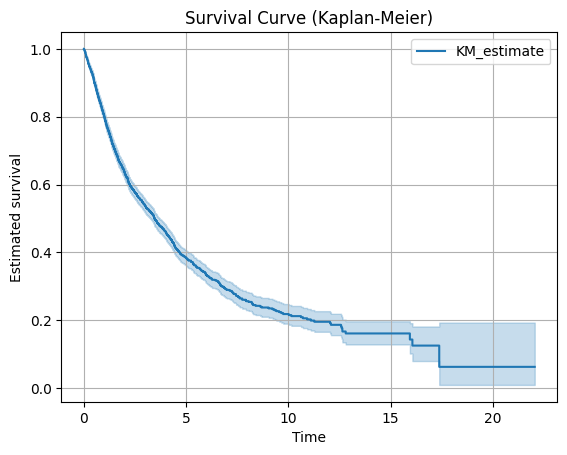

In [22]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Initialisation
kmf = KaplanMeierFitter()

# Ajustement du modèle
kmf.fit(durations=df_significant['time'], event_observed=df_significant['event'])

# Affichage de la courbe
kmf.plot_survival_function()
plt.title("Survival Curve (Kaplan-Meier)")
plt.xlabel("Time")
plt.ylabel("Estimated survival")
plt.grid()
plt.show()

In [23]:
df_significant = pl.from_pandas(df_significant)
df_significant = df_significant.with_columns(
    pl.when(pl.col("is_a_Female") == 1).then(0).otherwise(1).alias("is_a_Male")
)
df_significant

BM_BLAST,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,is_down_syndrome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_complex_karyo,GENE_count,START_mean,has_PTD,is_transition,is_transversion,time,event,is_a_Male
f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,bool,i32
0.756757,0.291667,0.246835,1,0,1,0,0,0,0,0,0.5,0.189604,0.0,1.0,1.0,1.115068,true,1
0.054054,0.662037,0.084388,0,1,0,0,0,0,0,0,0.125,0.106457,0.0,1.0,0.0,4.928767,false,0
0.810811,0.902778,0.166667,1,0,0,0,0,0,0,0,0.125,0.601459,0.0,1.0,1.0,2.043836,false,1
0.054054,0.412037,0.158228,1,0,1,0,0,0,0,0,0.625,0.318923,0.0,1.0,1.0,2.476712,true,1
0.324324,0.615741,0.407173,0,1,0,0,0,0,0,0,0.0,0.141938,0.0,0.0,0.0,3.145205,false,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.054054,0.412037,1.0,1,0,0,0,0,0,0,0,0.0625,0.169665,0.0,0.0,1.0,2.932591,false,1
0.0,0.569444,0.099156,1,0,1,0,0,1,0,1,0.0,0.24991,0.0,1.0,0.0,2.932591,false,1
0.0,0.458333,0.177215,1,0,1,0,0,0,0,0,0.3125,0.383896,0.0,1.0,1.0,1.99726,false,1


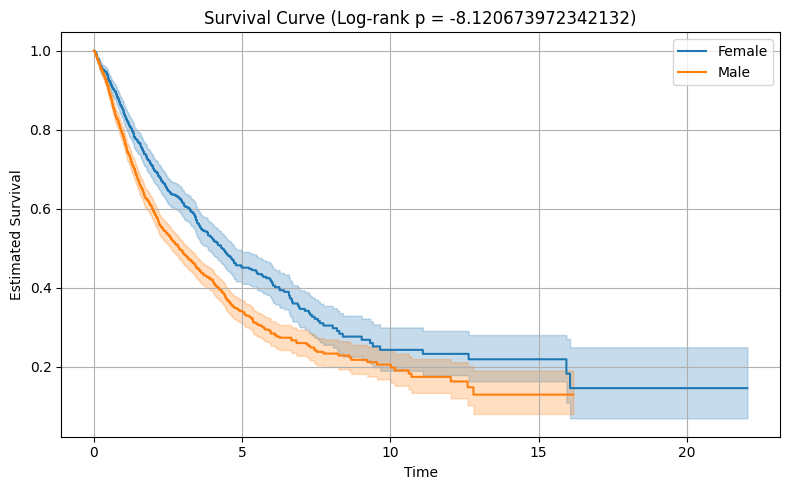

In [24]:
from lifelines.statistics import logrank_test

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

data_A = df_significant.filter(pl.col("is_a_Female") == 1)
data_B = df_significant.filter(pl.col("is_a_Female") == 0)

# Plot survival functions
plt.figure(figsize=(8, 5))
kmf_A.fit(data_A['time'], data_A['event'], label='Female')
kmf_A.plot_survival_function()

kmf_B.fit(data_B['time'], data_B['event'], label='Male')
kmf_B.plot_survival_function()

# Perform log-rank test
results = logrank_test(
    data_A['time'], data_B['time'],
    event_observed_A=data_A['event'],
    event_observed_B=data_B['event']
)

# Add p-value to the plot
plt.title(f"Survival Curve (Log-rank p = {np.log10(results.p_value)})")
plt.xlabel("Time")
plt.ylabel("Estimated Survival")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

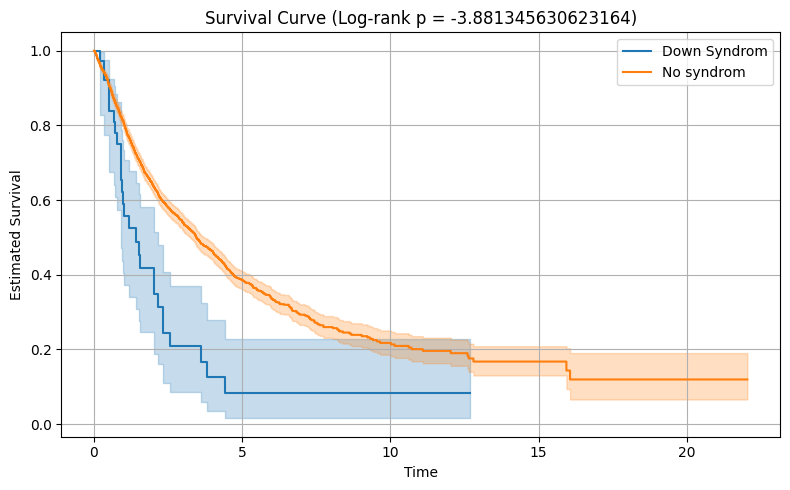

In [25]:
from lifelines.statistics import logrank_test

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

data_A = df_significant.filter(pl.col("is_down_syndrome") == 1)
data_B = df_significant.filter(pl.col("is_down_syndrome") == 0)

# Plot survival functions
plt.figure(figsize=(8, 5))
kmf_A.fit(data_A['time'], data_A['event'], label='Down Syndrom')
kmf_A.plot_survival_function()

kmf_B.fit(data_B['time'], data_B['event'], label='No syndrom')
kmf_B.plot_survival_function()

# Perform log-rank test
results = logrank_test(
    data_A['time'], data_B['time'],
    event_observed_A=data_A['event'],
    event_observed_B=data_B['event']
)

# Add p-value to the plot
plt.title(f"Survival Curve (Log-rank p = {np.log10(results.p_value)})")
plt.xlabel("Time")
plt.ylabel("Estimated Survival")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

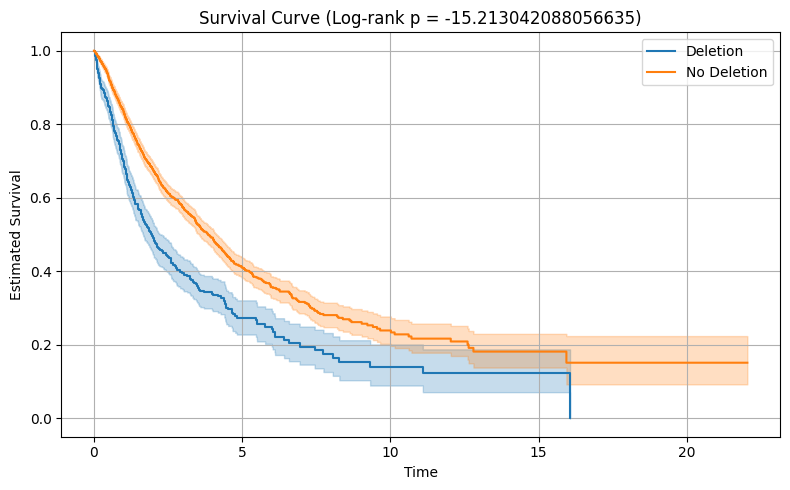

In [27]:
from lifelines.statistics import logrank_test

kmf_A = KaplanMeierFitter()
kmf_B = KaplanMeierFitter()

data_A = df_significant.filter(pl.col("is_deletion_anomaly") == 1)
data_B = df_significant.filter(pl.col("is_deletion_anomaly") == 0)

# Plot survival functions
plt.figure(figsize=(8, 5))
kmf_A.fit(data_A['time'], data_A['event'], label='Deletion')
kmf_A.plot_survival_function()

kmf_B.fit(data_B['time'], data_B['event'], label='No Deletion')
kmf_B.plot_survival_function()

# Perform log-rank test
results = logrank_test(
    data_A['time'], data_B['time'],
    event_observed_A=data_A['event'],
    event_observed_B=data_B['event']
)

# Add p-value to the plot
plt.title(f"Survival Curve (Log-rank p = {np.log10(results.p_value)})")
plt.xlabel("Time")
plt.ylabel("Estimated Survival")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# TestDataFrame

In [49]:
mol_test = pl.read_csv("../data/processed/X_test/molecular_test.csv")

mol_test

ID,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,CHR_mean,CHR_max,CHR_min,has_stop_lost,has_ITD,has_None,has_inframe_codon_loss,has_PTD,has_non_synonymous_codon,has_frameshift_variant,has_inframe_codon_gain,has_stop_gained,REF_length,ALT_length,is_transition,is_transversion,is_indel
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64
"""KYW121""",0.230769,0.383175,0.469,0.2007,0.429521,0.654048,0.211653,0.232963,0.49541,0.001369,0.642857,21.0,4.0,0,1,0,0,0,1,1,0,1,0.050847,0.096774,1,0,0
"""KYW132""",0.076923,0.3615,0.499,0.224,0.3677,0.604913,0.144273,0.047541,0.082814,0.030304,0.571429,17.0,9.0,0,0,0,0,0,1,0,0,0,0.033898,0.064516,1,1,0
"""KYW703""",0.153846,0.322,0.482,0.201,0.389314,0.554974,0.130004,0.77137,0.842317,0.636242,0.190476,5.0,5.0,0,0,0,0,0,1,1,0,0,0.050847,0.096774,1,0,0
"""KYW1142""",0.230769,0.2645,0.574,0.071,0.240032,0.417237,0.070551,0.330849,0.495449,0.030303,0.488095,17.0,4.0,0,0,0,1,0,0,1,0,1,0.474576,0.258065,1,0,1
"""KYW877""",0.153846,0.348667,0.469,0.226,0.295073,0.362465,0.252874,0.565635,0.842317,0.030306,0.380952,17.0,5.0,0,0,0,0,0,1,1,0,0,0.050847,0.096774,1,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KYW48""",0.0,0.618,0.618,0.618,0.009666,0.009666,0.025367,0.012271,0.012271,0.030306,0.761905,17.0,17.0,0,0,0,0,0,1,0,0,0,0.016949,0.032258,1,0,0
"""KYW1082""",0.384615,0.3881,0.925,0.162,0.256813,0.455095,0.089576,0.439561,1.0,0.131421,0.547619,17.0,2.0,0,1,0,1,1,1,0,0,1,0.457627,0.129032,1,1,1
"""KYW1118""",0.0,0.851,0.851,0.851,0.474426,0.474426,0.482759,0.012271,0.012271,0.030306,0.761905,17.0,17.0,0,0,0,0,0,1,0,0,0,0.016949,0.032258,0,1,0


In [50]:
mol_test = mol_test.drop("has_None")

In [51]:
cl_test = pl.read_csv("../data/processed/X_test/clinical_test_preprocess.csv")

cl_test

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_normal_cyto,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""KYW1""",1.0,0.329356,0.101295,0.0324,0.393519,0.15894,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
"""KYW2""",0.886076,0.30358,0.214197,0.0311,0.615741,0.10596,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,1
"""KYW3""",1.0,1.0,1.0,0.93675,0.828704,0.082781,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
"""KYW4""",1.0,0.529833,0.354663,0.93675,0.430556,0.145695,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
"""KYW5""",0.050633,0.115513,0.127478,0.03,0.486111,0.089404,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KYW1189""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
"""KYW1190""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
"""KYW1191""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [52]:
test_merged = cl_test.join(mol_test,on="ID",how="left")

test_merged

ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_normal_cyto,is_a_Man,is_a_Female,is_deletion_anomaly,is_inversion_anomaly,is_added_anomaly,is_down_syndrome,is_monosomy,is_7_deleted,is_trisomy_8,iso_chromosome,is_derived_chromosome,is_lost_sex_chromosome,is_added_chromsome,is_deleted_chromsome,is_inserted_chromsome,is_translocated_anomaly,is_complex_karyo,GENE_count,VAF_mean,VAF_max,VAF_min,DEPTH_mean,DEPTH_max,DEPTH_min,START_mean,START_max,START_min,CHR_mean,CHR_max,CHR_min,has_stop_lost,has_ITD,has_inframe_codon_loss,has_PTD,has_non_synonymous_codon,has_frameshift_variant,has_inframe_codon_gain,has_stop_gained,REF_length,ALT_length,is_transition,is_transversion,is_indel
str,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,i64
"""KYW1""",1.0,0.329356,0.101295,0.0324,0.393519,0.15894,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.230769,0.246225,0.384,0.027,0.350584,0.608941,0.185493,0.486145,0.812411,0.116384,0.130952,7.0,1.0,0,1,0,0,1,1,0,1,0.050847,0.193548,0,1,1
"""KYW2""",0.886076,0.30358,0.214197,0.0311,0.615741,0.10596,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,1,0.153846,0.281,0.713,0.058,0.52893,0.648409,0.326595,0.413086,0.540018,0.18598,0.428571,17.0,1.0,0,0,0,0,1,0,0,1,0.050847,0.096774,1,1,0
"""KYW3""",1.0,1.0,1.0,0.93675,0.828704,0.082781,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0.153846,0.162667,0.327,0.037,0.873674,0.946436,0.837891,0.249923,0.495417,0.143113,0.650794,20.0,4.0,0,0,0,0,0,1,0,1,0.067797,0.096774,1,0,1
"""KYW4""",1.0,0.529833,0.354663,0.93675,0.430556,0.145695,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.153846,0.351367,0.428,0.2021,0.710699,0.984293,0.211653,0.195887,0.300836,0.149826,0.714286,21.0,11.0,0,1,0,0,0,1,0,1,0.033898,0.064516,0,0,0
"""KYW5""",0.050633,0.115513,0.127478,0.03,0.486111,0.089404,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0.153846,0.263667,0.407,0.035,0.622365,0.687072,0.55648,0.1945,0.263023,0.143114,0.873016,21.0,17.0,0,0,0,0,1,0,0,1,0.050847,0.096774,1,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""KYW1189""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.076923,0.4455,0.475,0.416,0.490938,0.674184,0.318668,0.161868,0.189564,0.149981,0.357143,11.0,6.0,0,0,0,0,1,0,0,0,0.033898,0.064516,0,1,0
"""KYW1190""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.153846,0.438667,0.648,0.113,0.141227,0.214257,0.068966,0.389875,0.540007,0.149979,0.206349,11.0,1.0,0,0,0,0,1,1,0,0,0.271186,0.096774,0,1,1
"""KYW1191""",0.35443,0.105012,0.037047,0.026,0.486111,0.089404,0,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,0.0,0.122,0.122,0.122,0.720097,0.720097,0.724534,0.012271,0.012271,0.030306,0.761905,17.0,17.0,0,0,0,0,1,0,0,0,0.016949,0.032258,1,0,0


In [ ]:
from sklearn.tree import DecisionTreeRegressor

cols = mol_test.columns

cols.remove("ID")

estimator = DecisionTreeRegressor(
)

test_merged = imputation_null_values(test_merged,cols , estimator=estimator)

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [54]:
x_test = test_merged.to_pandas()

In [55]:
x_test = x_test.drop("is_normal_cyto" , axis=1)

In [56]:
x_train = final_df.to_pandas()

x_train

,ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,...,has_splice_site_variant,has_complex_change_in_transcript,has_stop_lost,REF_length,ALT_length,is_transition,is_transversion,is_indel,time,event
0,P132697,0.756757,0.209677,0.025890,0.70,0.291667,0.246835,1,0,1,...,0.0,0.0,0.0,0.015517,0.147727,1.0,1.0,1.0,1.115068,True
1,P132698,0.054054,0.580645,0.310680,0.10,0.662037,0.084388,0,1,0,...,0.0,0.0,0.0,0.005172,0.056818,1.0,0.0,1.0,4.928767,False
2,P116889,0.810811,0.282258,0.271845,0.10,0.902778,0.166667,1,0,0,...,0.0,0.0,0.0,0.005172,0.034091,1.0,1.0,0.0,2.043836,False
3,P132699,0.054054,0.298387,0.245955,0.10,0.412037,0.158228,1,0,1,...,1.0,0.0,0.0,0.058621,0.136364,1.0,1.0,1.0,2.476712,True
4,P132700,0.324324,1.000000,1.000000,0.90,0.615741,0.407173,0,1,0,...,0.0,0.0,0.0,0.001724,0.022727,0.0,0.0,1.0,3.145205,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318,P121828,0.054054,0.282258,0.327508,0.53,0.412037,1.000000,1,0,0,...,0.0,0.0,0.0,0.003448,0.034091,0.0,1.0,1.0,2.932591,False
3319,P121829,0.000000,0.322581,0.310680,0.22,0.569444,0.099156,1,0,1,...,0.0,0.0,0.0,0.001724,0.011364,1.0,0.0,0.0,2.932591,False
3320,P121830,0.000000,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,...,0.0,0.0,0.0,0.012069,0.068182,1.0,1.0,1.0,1.997260,False
3321,P121853,0.270270,0.094355,0.047896,0.11,0.643519,0.210970,0,1,1,...,0.0,0.0,0.0,0.006897,0.045455,1.0,1.0,0.0,0.095890,True


In [57]:
for col in x_train.columns:
    if col not in x_test.columns:
        print(col)

has_3_prime_UTR_variant
has_2KB_upstream_variant
has_initiator_codon_change
has_inframe_variant
has_synonymous_codon
has_splice_site_variant
has_complex_change_in_transcript
time
event


In [58]:
x_train = x_train.drop([
    "has_initiator_codon_change",
    "has_2KB_upstream_variant",
    "has_complex_change_in_transcript",
    "has_3_prime_UTR_variant",
    "has_synonymous_codon",
    "has_inframe_variant",
    "has_splice_site_variant"
] , axis=1)


In [59]:
x_train

,ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,...,has_stop_gained,has_inframe_codon_loss,has_stop_lost,REF_length,ALT_length,is_transition,is_transversion,is_indel,time,event
0,P132697,0.756757,0.209677,0.025890,0.70,0.291667,0.246835,1,0,1,...,1.0,0.0,0.0,0.015517,0.147727,1.0,1.0,1.0,1.115068,True
1,P132698,0.054054,0.580645,0.310680,0.10,0.662037,0.084388,0,1,0,...,1.0,0.0,0.0,0.005172,0.056818,1.0,0.0,1.0,4.928767,False
2,P116889,0.810811,0.282258,0.271845,0.10,0.902778,0.166667,1,0,0,...,1.0,0.0,0.0,0.005172,0.034091,1.0,1.0,0.0,2.043836,False
3,P132699,0.054054,0.298387,0.245955,0.10,0.412037,0.158228,1,0,1,...,0.0,0.0,0.0,0.058621,0.136364,1.0,1.0,1.0,2.476712,True
4,P132700,0.324324,1.000000,1.000000,0.90,0.615741,0.407173,0,1,0,...,0.0,0.0,0.0,0.001724,0.022727,0.0,0.0,1.0,3.145205,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318,P121828,0.054054,0.282258,0.327508,0.53,0.412037,1.000000,1,0,0,...,0.0,0.0,0.0,0.003448,0.034091,0.0,1.0,1.0,2.932591,False
3319,P121829,0.000000,0.322581,0.310680,0.22,0.569444,0.099156,1,0,1,...,0.0,0.0,0.0,0.001724,0.011364,1.0,0.0,0.0,2.932591,False
3320,P121830,0.000000,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,...,1.0,0.0,0.0,0.012069,0.068182,1.0,1.0,1.0,1.997260,False
3321,P121853,0.270270,0.094355,0.047896,0.11,0.643519,0.210970,0,1,1,...,0.0,0.0,0.0,0.006897,0.045455,1.0,1.0,0.0,0.095890,True


In [60]:
common_cols = [col for col in x_train.columns if col in x_test.columns]
x_test = x_test[common_cols]

In [61]:
x_test

,ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,...,has_frameshift_variant,has_ITD,has_stop_gained,has_inframe_codon_loss,has_stop_lost,REF_length,ALT_length,is_transition,is_transversion,is_indel
0,KYW1,1.000000,0.329356,0.101295,0.03240,0.393519,0.158940,0,0,1,...,1.0,1.0,1.0,0.0,0.0,0.050847,0.193548,0.0,1.0,1.0
1,KYW2,0.886076,0.303580,0.214197,0.03110,0.615741,0.105960,1,0,1,...,0.0,0.0,1.0,0.0,0.0,0.050847,0.096774,1.0,1.0,0.0
2,KYW3,1.000000,1.000000,1.000000,0.93675,0.828704,0.082781,0,0,0,...,1.0,0.0,1.0,0.0,0.0,0.067797,0.096774,1.0,0.0,1.0
3,KYW4,1.000000,0.529833,0.354663,0.93675,0.430556,0.145695,0,0,0,...,1.0,1.0,1.0,0.0,0.0,0.033898,0.064516,0.0,0.0,0.0
4,KYW5,0.050633,0.115513,0.127478,0.03000,0.486111,0.089404,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.050847,0.096774,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188,KYW1189,0.354430,0.105012,0.037047,0.02600,0.486111,0.089404,-1,-1,-1,...,0.0,0.0,0.0,0.0,0.0,0.033898,0.064516,0.0,1.0,0.0
1189,KYW1190,0.354430,0.105012,0.037047,0.02600,0.486111,0.089404,-1,-1,-1,...,1.0,0.0,0.0,0.0,0.0,0.271186,0.096774,0.0,1.0,1.0
1190,KYW1191,0.354430,0.105012,0.037047,0.02600,0.486111,0.089404,-1,-1,-1,...,0.0,0.0,0.0,0.0,0.0,0.016949,0.032258,1.0,0.0,0.0
1191,KYW1192,0.354430,0.105012,0.037047,0.02600,0.486111,0.089404,-1,-1,-1,...,1.0,0.0,0.0,0.0,0.0,0.050847,0.096774,1.0,0.0,0.0


In [62]:
from sksurv.ensemble import RandomSurvivalForest


model = RandomSurvivalForest(
    n_estimators=234,
    max_depth=9,
    max_features="log2",
    min_samples_leaf=10,
    min_samples_split=16,
    random_state=42,
    
    n_jobs=-1
)

X_train = x_train.drop(["time" , "event"] , axis=1)

y_train = Surv.from_dataframe(event = 'event' , time='time' , data=x_train)

X_train

,ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,is_a_Man,is_a_Female,is_deletion_anomaly,...,has_frameshift_variant,has_ITD,has_stop_gained,has_inframe_codon_loss,has_stop_lost,REF_length,ALT_length,is_transition,is_transversion,is_indel
0,P132697,0.756757,0.209677,0.025890,0.70,0.291667,0.246835,1,0,1,...,1.0,0.0,1.0,0.0,0.0,0.015517,0.147727,1.0,1.0,1.0
1,P132698,0.054054,0.580645,0.310680,0.10,0.662037,0.084388,0,1,0,...,1.0,0.0,1.0,0.0,0.0,0.005172,0.056818,1.0,0.0,1.0
2,P116889,0.810811,0.282258,0.271845,0.10,0.902778,0.166667,1,0,0,...,0.0,0.0,1.0,0.0,0.0,0.005172,0.034091,1.0,1.0,0.0
3,P132699,0.054054,0.298387,0.245955,0.10,0.412037,0.158228,1,0,1,...,1.0,0.0,0.0,0.0,0.0,0.058621,0.136364,1.0,1.0,1.0
4,P132700,0.324324,1.000000,1.000000,0.90,0.615741,0.407173,0,1,0,...,1.0,0.0,0.0,0.0,0.0,0.001724,0.022727,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3318,P121828,0.054054,0.282258,0.327508,0.53,0.412037,1.000000,1,0,0,...,1.0,0.0,0.0,0.0,0.0,0.003448,0.034091,0.0,1.0,1.0
3319,P121829,0.000000,0.322581,0.310680,0.22,0.569444,0.099156,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.001724,0.011364,1.0,0.0,0.0
3320,P121830,0.000000,0.129032,0.071197,0.29,0.458333,0.177215,1,0,1,...,1.0,0.0,1.0,0.0,0.0,0.012069,0.068182,1.0,1.0,1.0
3321,P121853,0.270270,0.094355,0.047896,0.11,0.643519,0.210970,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.006897,0.045455,1.0,1.0,0.0


In [63]:
X_train = X_train.drop("ID" , axis=1)

In [64]:
ids = x_test["ID"]
x_test_no_id = x_test.drop(columns=["ID"])

In [65]:
model.fit(X_train, y_train)

y_pred = model.predict(x_test_no_id)

results = pd.DataFrame({
    "ID": ids,
    "y_pred": y_pred
})

results

,ID,y_pred
0,KYW1,794.186777
1,KYW2,1098.668308
2,KYW3,937.818160
3,KYW4,942.293618
4,KYW5,1132.288307
...,...,...
1188,KYW1189,728.716390
1189,KYW1190,736.235881
1190,KYW1191,926.537958
1191,KYW1192,573.052816


In [66]:
results = results.rename(columns={"y_pred" : "risk_score"})

In [67]:
results

,ID,risk_score
0,KYW1,794.186777
1,KYW2,1098.668308
2,KYW3,937.818160
3,KYW4,942.293618
4,KYW5,1132.288307
...,...,...
1188,KYW1189,728.716390
1189,KYW1190,736.235881
1190,KYW1191,926.537958
1191,KYW1192,573.052816


In [68]:
results = pl.from_pandas(results)

results

ID,risk_score
str,f64
"""KYW1""",794.186777
"""KYW2""",1098.668308
"""KYW3""",937.81816
"""KYW4""",942.293618
"""KYW5""",1132.288307
…,…
"""KYW1189""",728.71639
"""KYW1190""",736.235881
"""KYW1191""",926.537958


In [69]:
exported_res = results.write_csv("../data/final_res.csv")